 **Import Dependecies**

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from keras.preprocessing import image
from matplotlib import pyplot as plt
from matplotlib.image import imread
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np
import zipfile
import keras
import cv2
import sys
import os

**Define the training and testing data paths**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define the path to the ZIP file in Google Drive
zip_path = '/content/drive/My Drive/dataset.zip'
extract_path = '/content/dataset/'

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List the contents of the extracted directory
os.listdir(extract_path)

['dataset']

In [7]:
#train_data_path = r'leaf-disease-detection-dataset\\dataset\\train'
#test_data_path = r'leaf-disease-detection-dataset\\dataset\\test'

train_data_path = r'/content/dataset/dataset/train'
test_data_path = r'/content/dataset/dataset/test'

 **Show number of images and classes in the dataset**

In [8]:
def count_classes(data_path): #no of classes in the dataset
    num_classes = len(os.listdir(data_path))
    return num_classes

def count_images(data_path): #no of images in the dataset
    count = 0
    data_path = os.listdir(data_path)
    for folder in data_path:
        count += len(os.listdir(train_data_path + '/' + folder))
    return count

num_classes = count_classes(train_data_path)

print(f"Our data contains {num_classes} classes")
print(f"Our Training data has {count_images(train_data_path)} images")

Our data contains 44 classes
Our Training data has 43868 images


In [9]:
def main(train_data_path, test_data_path): #return training and testing df
    for dirs in [train_data_path, test_data_path]:
        filepaths = []
        labels = []
        classes_list = sorted(os.listdir(dirs))
        filepaths,labels = get_fileList(classes_list, dirs, filepaths, labels)
        if dirs == train_data_path:
            train_df = obtain_train_df(filepaths, labels)
        else:
            test_df = obtain_test_df(filepaths, labels)
    return train_df, test_df



def get_fileList(classes_list, dirs, filepaths, labels): #filepaths' list
    for s_class in classes_list:
        label = s_class.split('__')[1]
        classpath = os.path.join(dirs, s_class)
        flist = sorted(os.listdir(classpath))
        store_image_names_and_its_labels(flist, classpath, filepaths, labels, label)
    return filepaths, labels


def store_image_names_and_its_labels(flist, classpath, filepaths, labels, label):
    for file in flist:
        file_path = os.path.join(classpath, file)
        filepaths.append(file_path)
        labels.append(label)


def obtain_train_df(filepaths, labels):
    train_df =pd.DataFrame({
        'image_path' : filepaths,
        'label' : labels
    })
    return train_df

def obtain_test_df(filepaths, labels):

    test_df =pd.DataFrame({
        'image_path' : filepaths,
        'label' : labels
    })
    return test_df

In [10]:
train_df, test_df = main(train_data_path, test_data_path)

In [11]:
train_df.shape
train_df.head()

,image_path,label
0,/content/dataset/dataset/train/Apple___Apple_s...,_Apple_scab
1,/content/dataset/dataset/train/Apple___Apple_s...,_Apple_scab
2,/content/dataset/dataset/train/Apple___Apple_s...,_Apple_scab
3,/content/dataset/dataset/train/Apple___Apple_s...,_Apple_scab
4,/content/dataset/dataset/train/Apple___Apple_s...,_Apple_scab


In [12]:
test_df.shape
test_df.head()

,image_path,label
0,/content/dataset/dataset/test/Apple___Apple_sc...,_Apple_scab
1,/content/dataset/dataset/test/Apple___Apple_sc...,_Apple_scab
2,/content/dataset/dataset/test/Apple___Apple_sc...,_Apple_scab
3,/content/dataset/dataset/test/Apple___Apple_sc...,_Apple_scab
4,/content/dataset/dataset/test/Apple___Apple_sc...,_Apple_scab


#**SPLITTING**

In [15]:
split_size = 0.2
train_df, val_df=train_test_split(train_df, test_size=split_size, shuffle=True, random_state=123, stratify=train_df['label'])

In [16]:
train_df.head()

,image_path,label
33259,/content/dataset/dataset/train/Tea__red_spot/i...,red_spot
38389,/content/dataset/dataset/train/Tomato___Septor...,_Septoria_leaf_spot
16053,/content/dataset/dataset/train/Peach___Bacteri...,_Bacterial_spot
17542,/content/dataset/dataset/train/Peach___healthy...,_healthy
11123,/content/dataset/dataset/train/Grape___Black_r...,_Black_rot


In [17]:
train_df.shape

(35094, 2)

In [18]:
val_df.head()

,image_path,label
3329,/content/dataset/dataset/train/Apple___healthy...,_healthy
4632,/content/dataset/dataset/train/Blueberry___hea...,_healthy
22344,/content/dataset/dataset/train/Potato___health...,_healthy
12113,/content/dataset/dataset/train/Grape___Esca_(B...,_Esca_(Black_Measles)
1359,/content/dataset/dataset/train/Apple___Black_r...,_Black_rot


In [19]:
val_df.shape

(8774, 2)

In [20]:
print(f"Our Training data contains {len(train_df)} images")
print(f"Our validation data contains {len(val_df)} images")
print(f"Our Testing data contains {len(test_df)} images")

Our Training data contains 35094 images
Our validation data contains 8774 images
Our Testing data contains 43867 images


**COUNT PLOTS**

In [21]:
def count_plot(x, title, xlabel, ylabel, width, length, order = None, rotation=False, palette='winter'):
    plt.figure(figsize=(width,length))
    sns.countplot(x = x, palette=palette, order = order)
    plt.title(title, fontsize=25)
    if rotation:
        plt.xticks(rotation = 'vertical')
    plt.xlabel(xlabel, fontsize=20)
    plt.ylabel(ylabel, fontsize=20)
    plt.show()

<ipython-input-21-655017a7263a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = x, palette=palette, order = order)


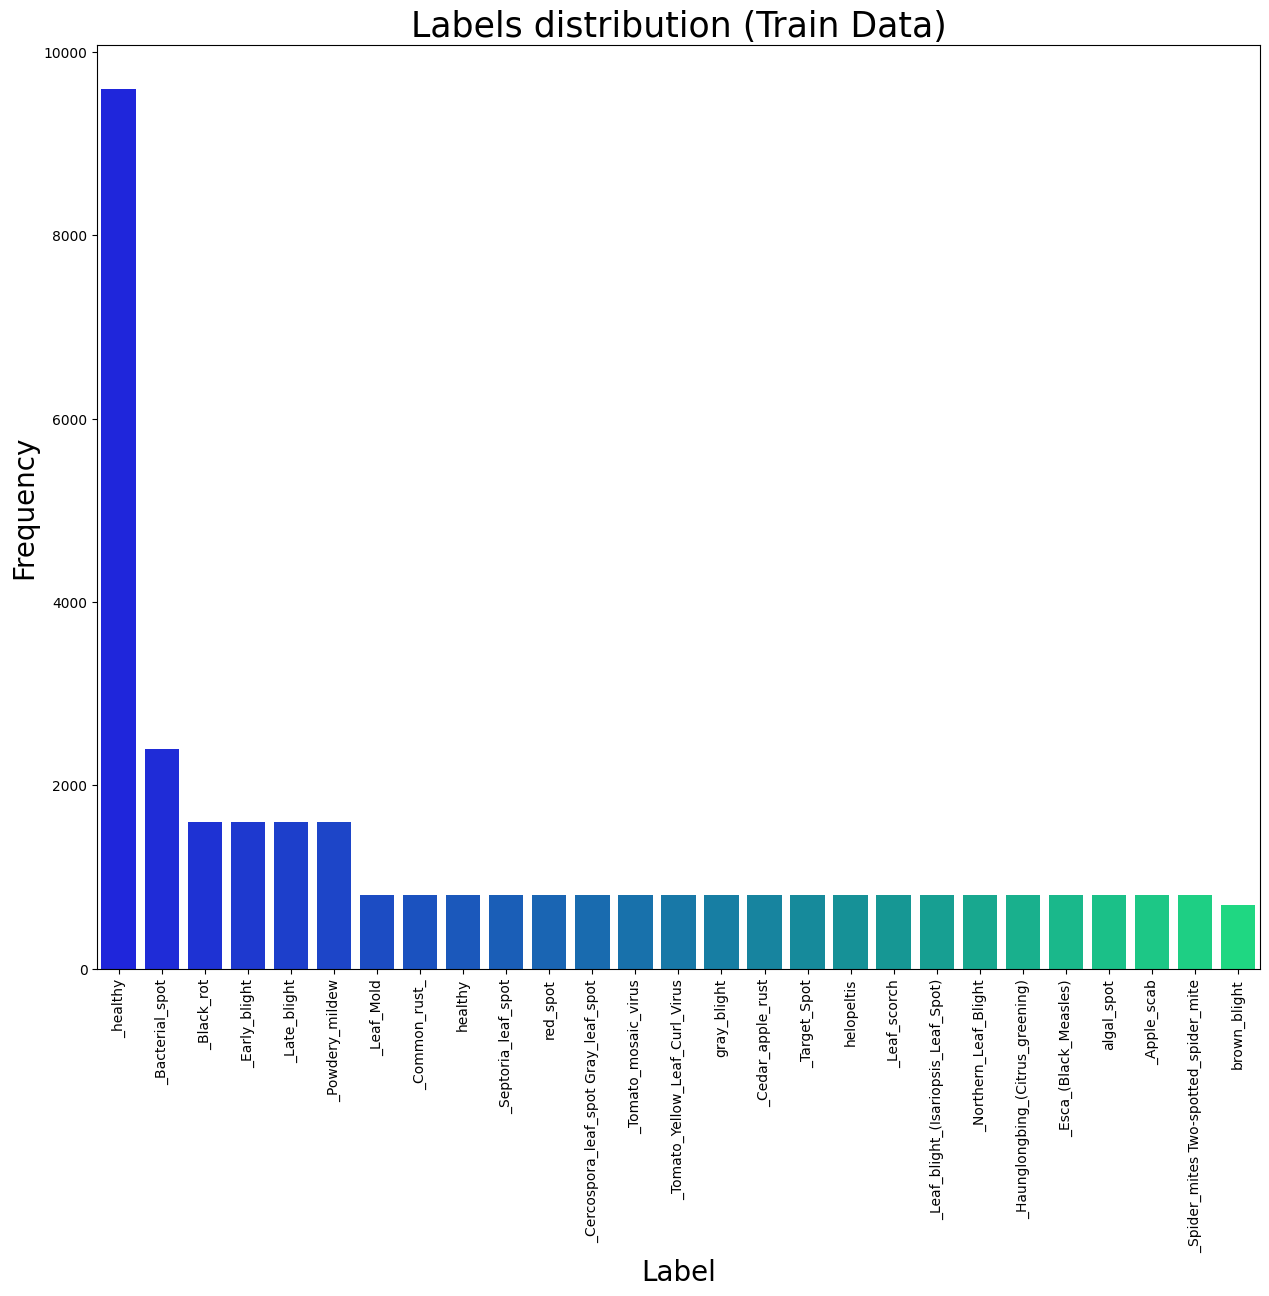

In [22]:
x = train_df['label']
order = x.value_counts().index
count_plot(x, "Labels distribution (Train Data)", "Label", 'Frequency', 15,12, rotation = True, order=order)

<ipython-input-21-655017a7263a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = x, palette=palette, order = order)


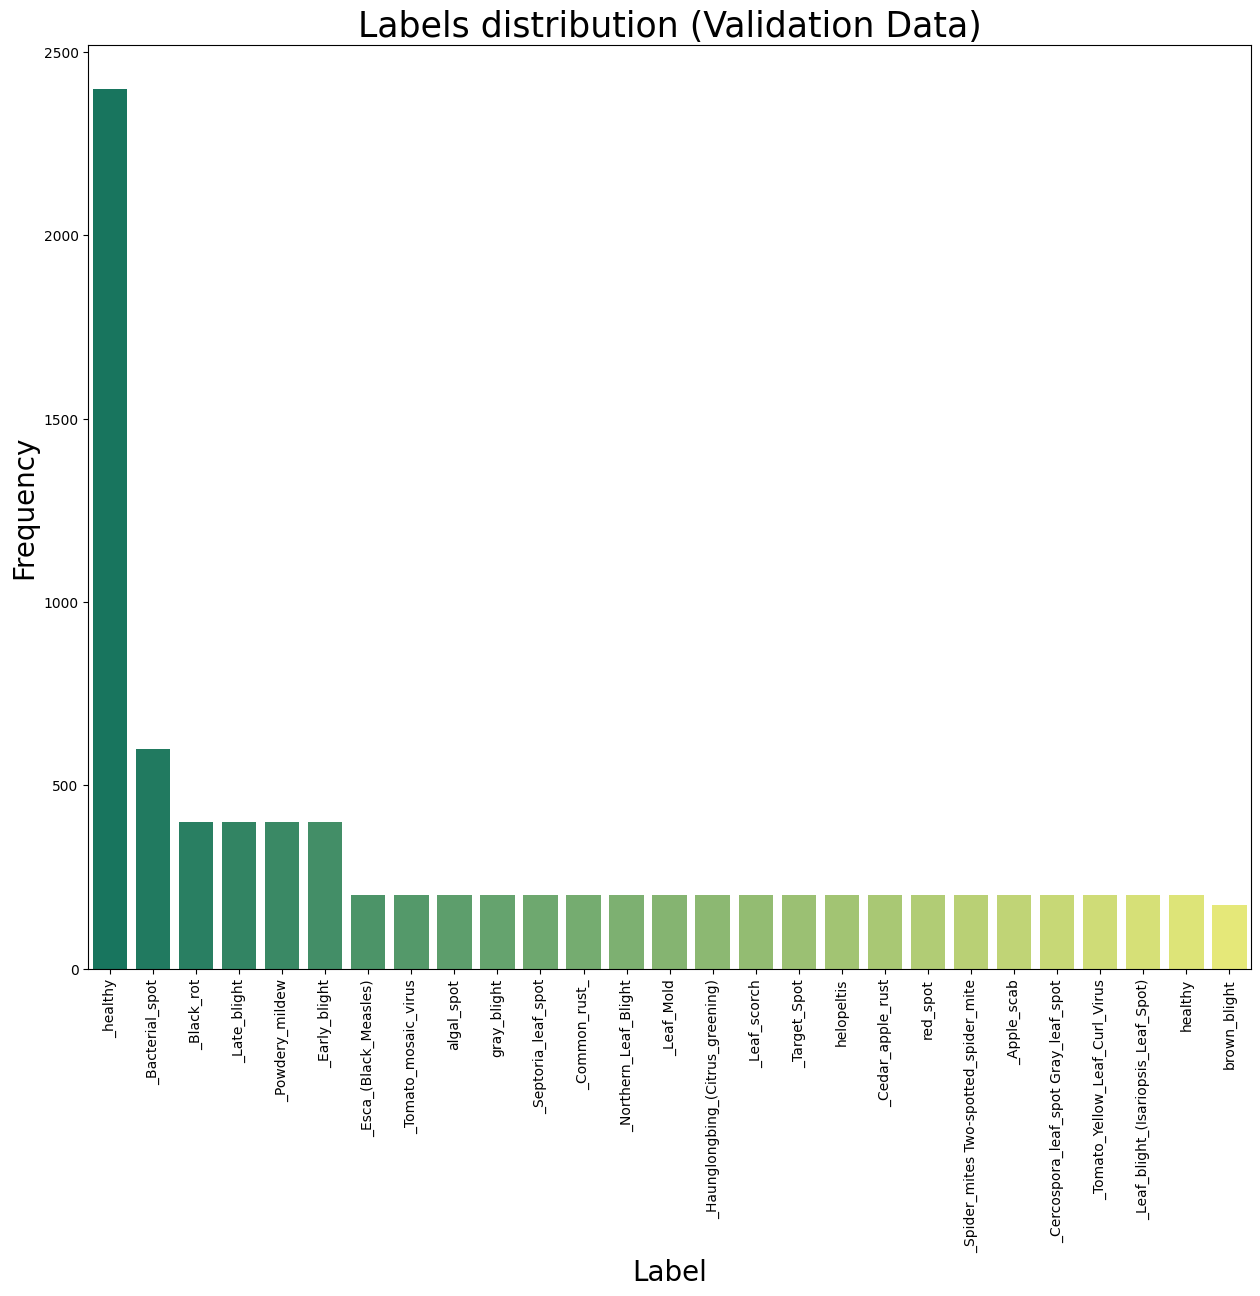

In [23]:
x = val_df['label']
order = x.value_counts().index
count_plot(x, "Labels distribution (Validation Data)", "Label", 'Frequency', 15,12, rotation = True, order=order, palette='summer')

<ipython-input-21-655017a7263a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = x, palette=palette, order = order)


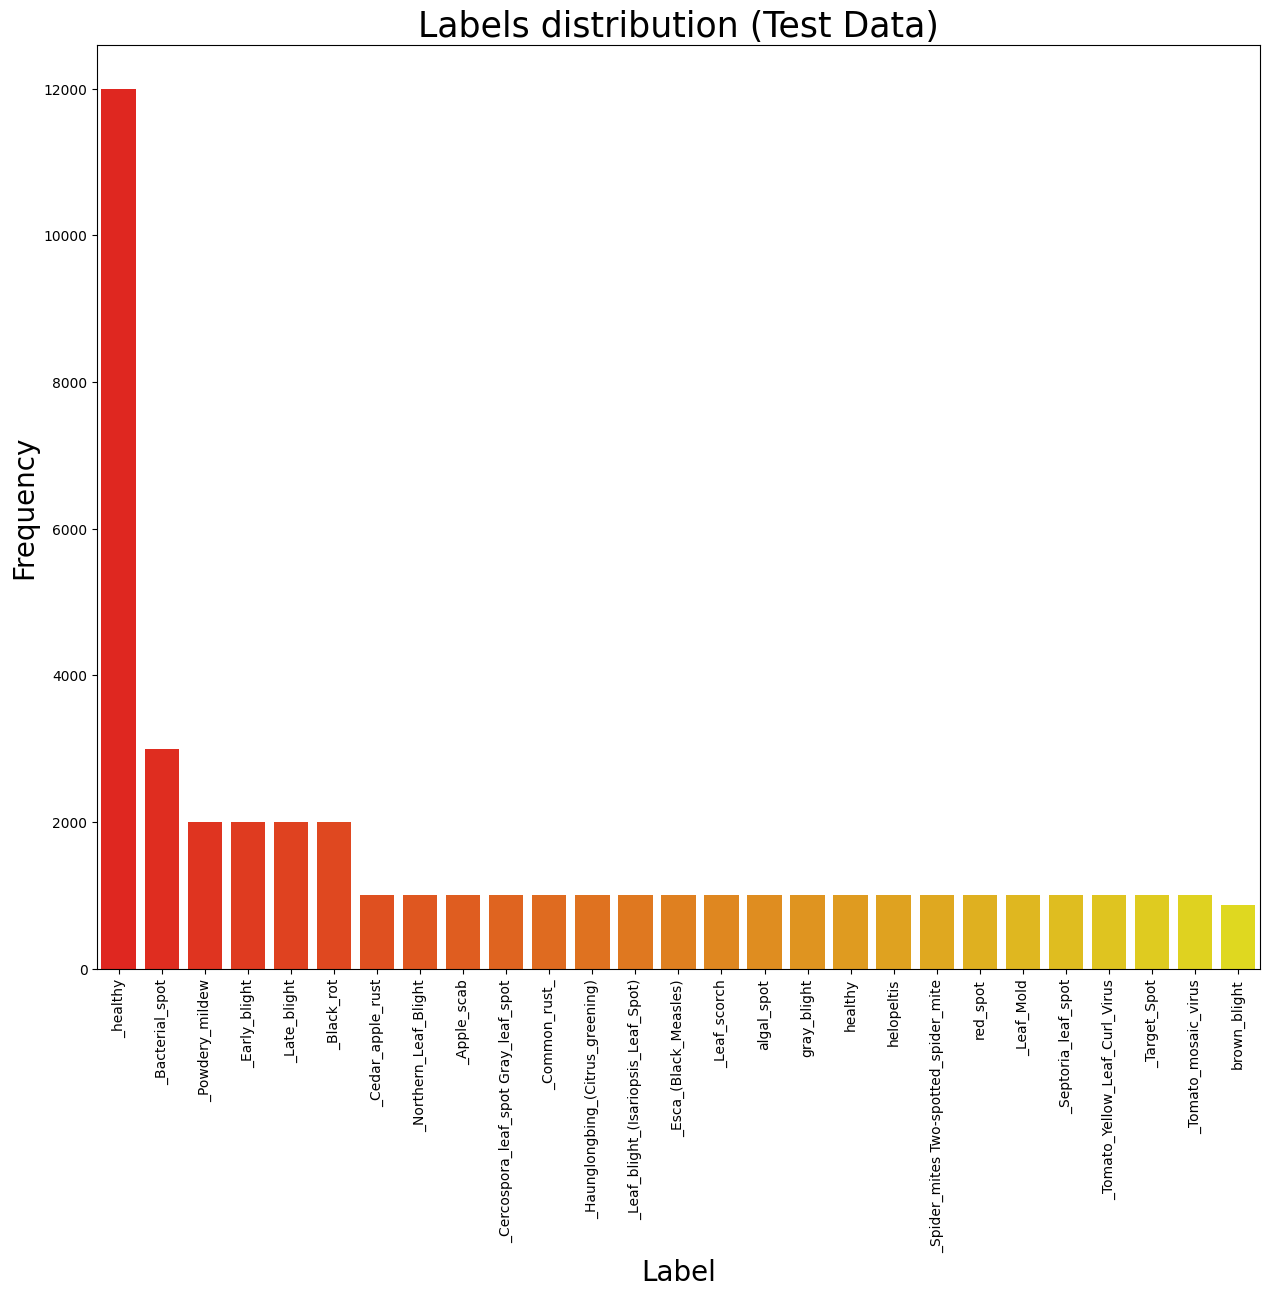

In [24]:
x = test_df['label']
order = x.value_counts().index
count_plot(x, "Labels distribution (Test Data)", "Label", 'Frequency', 15,12, rotation = True, order=order, palette='autumn')

**PRE-PROCESSING OF IMAGES**

In [25]:
def get_images_avg_width_height(df):
    avg_width, avg_height = 0,0
    for i in df.index:
        img_path = df['image_path'].loc[i]
        img = cv2.imread(img_path)
        avg_width += img.shape[0]
        avg_height += img.shape[1]
    avg_width // len(train_df)
    avg_height // len(test_df)
    return avg_width, avg_height

In [26]:
import cv2
import pandas as pd

def get_images_avg_width_height(df):
    total_width, total_height, valid_images = 0, 0, 0
    skipped_images = []

    for i in range(len(df)):
        try:
            img_path = df['image_path'].iloc[i]  # Use .iloc instead of .loc for positional indexing
        except KeyError as e:
            print(f"KeyError at index {i}: {e}")
            continue

        # Attempt to load the image
        img = cv2.imread(img_path)

        # Check if img is None (failed to load)
        if img is None:
            skipped_images.append(img_path)
            continue

        total_width += img.shape[1]
        total_height += img.shape[0]
        valid_images += 1

    if valid_images == 0:
        raise ValueError("No valid images found in the dataset.")

    avg_width = total_width // valid_images
    avg_height = total_height // valid_images

    print(f"Skipped {len(skipped_images)} images: {skipped_images}")

    return avg_width, avg_height, valid_images

# Example usage assuming train_df is defined somewhere in your code
avg_width_train, avg_height_train, num_images_train = get_images_avg_width_height(train_df)
print(f"Average width and height for training data: {avg_width_train}x{avg_height_train}, Number of valid images: {num_images_train}")


Skipped 1 images: ['/content/dataset/dataset/train/Tomato___Leaf_Mold/leaf-disease-detection-dataset - Shortcut.lnk']
Average width and height for training data: 256x255, Number of valid images: 35093


In [27]:
print(f"Average width and height for training data is {avg_width_train//len(train_df)}x{avg_height_train//len(train_df)} with aspect_ratio {avg_width_train/avg_height_train}")

Average width and height for training data is 0x0 with aspect_ratio 1.003921568627451


In [28]:
def get_images_avg_width_height(df):
    total_width, total_height, valid_images = 0, 0, 0
    for i in range(len(df)):
        img_path = df['image_path'].loc[i]
        if not img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')):
            print(f"Skipping non-image file at path {img_path}")
            continue
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Unable to load image at path {img_path}")
            continue
        total_width += img.shape[1]
        total_height += img.shape[0]
        valid_images += 1

    if valid_images == 0:
        raise ValueError("No valid images found in the dataset.")

    avg_width = total_width // valid_images
    avg_height = total_height // valid_images
    return avg_width, avg_height, valid_images

def resize_images_to_avg_dimensions(df, avg_width, avg_height):
    resized_images = []
    for i in range(len(df)):
        img_path = df['image_path'].loc[i]
        if not img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')):
            print(f"Skipping non-image file at path {img_path}")
            continue
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Unable to load image at path {img_path}")
            continue
        resized_img = cv2.resize(img, (avg_width, avg_height), interpolation=cv2.INTER_AREA)
        resized_images.append(resized_img)
    return resized_images

avg_width_test, avg_height_test, valid_images_count = get_images_avg_width_height(test_df)
print(f"Average width and height for testing data is {avg_width_test}x{avg_height_test} with aspect_ratio {avg_width_test / avg_height_test}")

resized_images = resize_images_to_avg_dimensions(test_df, avg_width_test, avg_height_test)

Average width and height for testing data is 256x255 with aspect_ratio 1.003921568627451


**TRAINING**

In [30]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set paths for your dataset
train_data_dir = r'/content/dataset/dataset/train'
test_data_dir = r'/content/dataset/dataset/test'

# ImageDataGenerator for data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1.0/255)
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

# Load the pre-trained DenseNet model without the top layer
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add new layers for our specific problem
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define EarlyStopping and ReduceLROnPlateau callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train the model with callbacks
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

# Optionally, unfreeze some layers of the base model and fine-tune
for layer in base_model.layers[-10:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with callbacks for fine-tuning
history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

# Save the model
model.save('leaf_detection_densenet_model.h5')

Found 43867 images belonging to 44 classes.
Found 43867 images belonging to 44 classes.
29084464/29084464 [==============================] - 2s 0us/step
Epoch 1/10
2741/2741 [==============================] - 531s 190ms/step - loss: 0.4858 - accuracy: 0.8468 - val_loss: 0.3056 - val_accuracy: 0.8954 - lr: 0.0010
Epoch 2/10
2741/2741 [==============================] - 515s 188ms/step - loss: 0.2516 - accuracy: 0.9136 - val_loss: 0.2647 - val_accuracy: 0.9165 - lr: 0.0010
Epoch 3/10
2741/2741 [==============================] - 515s 188ms/step - loss: 0.2038 - accuracy: 0.9310 - val_loss: 0.1277 - val_accuracy: 0.9549 - lr: 0.0010
Epoch 4/10
2741/2741 [==============================] - 513s 187ms/step - loss: 0.1690 - accuracy: 0.9418 - val_loss: 0.1318 - val_accuracy: 0.9524 - lr: 0.0010
Epoch 5/10
2741/2741 [==============================] - 512s 187ms/step - loss: 0.1555 - accuracy: 0.9455 - val_loss: 0.1297 - val_accuracy: 0.9550 - lr: 0.0010
Epoch 6/10
2741/2741 [====================

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


**EVALUATION**

In [33]:
# Display training and validation accuracy from the fine-tuning phase
train_acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']

print(f"Training Accuracy: {train_acc}")
print(f"Validation Accuracy: {val_acc}")

Training Accuracy: [0.9548014998435974, 0.9695788025856018, 0.9735468029975891, 0.9753711223602295, 0.9772410988807678, 0.9802740812301636, 0.9817563891410828, 0.9817336201667786, 0.9843789339065552, 0.9842420816421509]
Validation Accuracy: [0.9819865226745605, 0.9848595261573792, 0.9884622693061829, 0.9899215698242188, 0.9919509291648865, 0.9906968474388123, 0.9912896752357483, 0.9923841953277588, 0.9895567297935486, 0.9927718043327332]


In [34]:
def acc_curve(history):
    plt.plot(history_fine.history['accuracy'], label='train_acc')
    plt.plot(history_fine.history['val_accuracy'], label='val_acc')
    plt.title('Training and Validation Accuracy', fontsize=20)
    plt.xlabel('Epochs', fontsize = 15)
    plt.ylabel('Accuracy', fontsize = 15)
    plt.legend()
    plt.show()


def loss_curve(history):
    plt.plot(history_fine.history['loss'], label='train_loss')
    plt.plot(history_fine.history['val_loss'], label='val_loss')
    plt.title('Training and Validation Loss', fontsize=20)
    plt.xlabel('Epochs', fontsize=15)
    plt.ylabel('Loss', fontsize=15)
    plt.legend()
    plt.show()

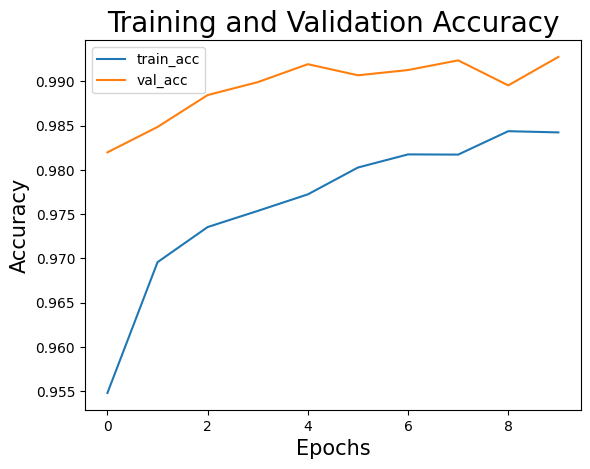

In [35]:
acc_curve(model)

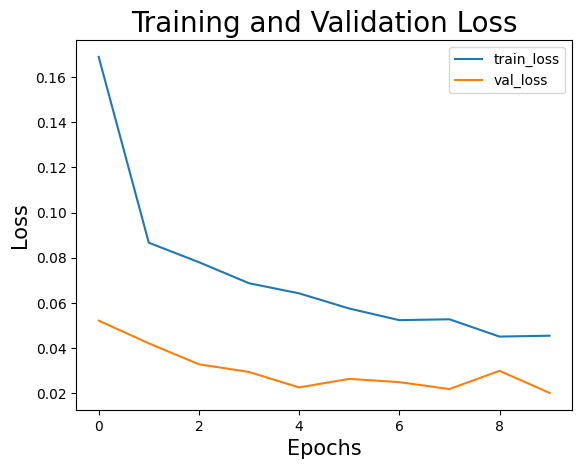

In [36]:
loss_curve(model)

Found 43867 images belonging to 44 classes.
2742/2742 [==============================] - 1728s 630ms/step - loss: 0.0202 - accuracy: 0.9927
Test Loss: 0.020179694518446922
Test Accuracy: 0.9927279949188232
2742/2742 [==============================] - 1381s 503ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00      1000
                                 Apple___Black_rot       1.00      1.00      1.00      1000
                          Apple___Cedar_apple_rust       1.00      1.00      1.00      1000
                                   Apple___healthy       1.00      1.00      1.00      1000
                               Blueberry___healthy       1.00      1.00      1.00      1000
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00      1000
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00      

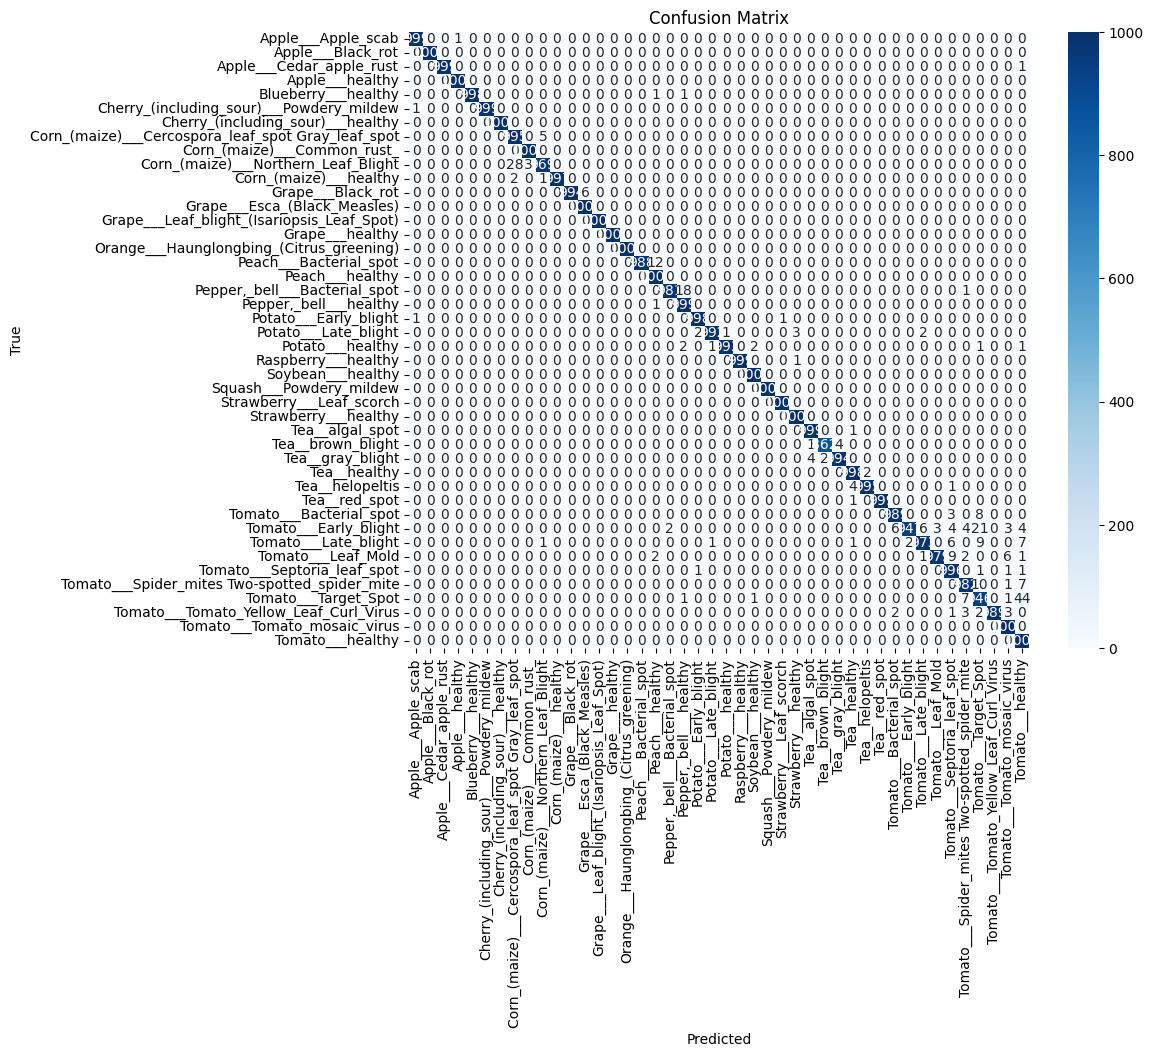

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths for your dataset
test_data_dir = r'leaf-disease-detection-dataset/dataset/test'

# ImageDataGenerator for data augmentation and preprocessing
test_datagen = ImageDataGenerator(rescale=1.0/255)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

# Load the trained model
model = load_model('leaf_detection_densenet_model.h5')

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

# Get the ground truth labels and predictions
Y_true = test_generator.classes
Y_pred = model.predict(test_generator)
Y_pred_classes = np.argmax(Y_pred, axis=1)

# Classification report
class_labels = list(test_generator.class_indices.keys())
report = classification_report(Y_true, Y_pred_classes, target_names=class_labels)
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**VERSIONS & DIRECTORY NAMES**

In [14]:
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("Python version:", sys.version)

TensorFlow version: 2.15.0
Keras version: 2.15.0
Python version: 3.10.12 | packaged by Anaconda, Inc. | (main, Jul  5 2023, 19:01:18) [MSC v.1916 64 bit (AMD64)]


In [51]:
import os

# Set path to your dataset folder
dataset_dir = r'/content/dataset/dataset/train'

# List all directories in the dataset folder
folder_names = [f.name for f in os.scandir(dataset_dir) if f.is_dir()]

# Sort the folder names
sorted_folders = sorted(folder_names)

# Format and print the folder names as an array
formatted_folders = ', '.join([f"'{folder}'" for folder in sorted_folders])
print(f"[{formatted_folders}]")


['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tea__algal_spot', 'Tea__brown_blight', 'Tea__gray_blight', 'Tea__healthy', 'Tea__helopeltis', 'Tea__red_spot', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato__